<a href="https://colab.research.google.com/github/DevKnight-code/DevKnight-code/blob/main/violence_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cpu
GPU available: False


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

print(os.listdir('/content/drive/MyDrive'))

['Untitled', 'video_20240402_231401.mp4', 'video_20240402_231352.mp4', 'video_20240402_231344.mp4', 'video_20240402_231147.mp4', 'VID20240402220740.mp4', 'video_20240402_220654.mp4', 'VID20240402220602.mp4', 'video_20240402_220625.mp4', 'VID20240402220032.mp4', 'video_20240402_215958.mp4', 'VID20240402215653.mp4', 'video_20240402_215631.mp4', 'video_20240402_215411.mp4', 'VID20240402215412.mp4', 'video_20240402_214921.mp4', 'video_20240402_215214.mp4', 'video_20240402_214735.mp4', 'video_20240402_214338.mp4', 'video_20240402_214052.mp4', 'VID20240402214055.mp4', 'video_20240402_213837.mp4', 'VID20240402214336.mp4', 'VID20240402213838.mp4', 'video_20240402_213700.mp4', 'VID20240402213656.mp4', 'video_20240402_213514.mp4', 'VID20240402213510.mp4', 'video_20240402_213015.mp4', 'VID20240402212241.mp4', 'VID20240402212030.mp4', 'VID20240402211634.mp4', 'video_20240402_174315.mp4', 'video_20240402_173810.mp4', 'video_20240402_173801.mp4', 'video_20240402_173725.mp4', 'VID20240402000420.mp4',

In [ ]:
import os

base_path = "/content/drive/MyDrive"

print(os.listdir(base_path))

['Untitled', 'video_20240402_231401.mp4', 'video_20240402_231352.mp4', 'video_20240402_231344.mp4', 'video_20240402_231147.mp4', 'VID20240402220740.mp4', 'video_20240402_220654.mp4', 'VID20240402220602.mp4', 'video_20240402_220625.mp4', 'VID20240402220032.mp4', 'video_20240402_215958.mp4', 'VID20240402215653.mp4', 'video_20240402_215631.mp4', 'video_20240402_215411.mp4', 'VID20240402215412.mp4', 'video_20240402_214921.mp4', 'video_20240402_215214.mp4', 'video_20240402_214735.mp4', 'video_20240402_214338.mp4', 'video_20240402_214052.mp4', 'VID20240402214055.mp4', 'video_20240402_213837.mp4', 'VID20240402214336.mp4', 'VID20240402213838.mp4', 'video_20240402_213700.mp4', 'VID20240402213656.mp4', 'video_20240402_213514.mp4', 'VID20240402213510.mp4', 'video_20240402_213015.mp4', 'VID20240402212241.mp4', 'VID20240402212030.mp4', 'VID20240402211634.mp4', 'video_20240402_174315.mp4', 'video_20240402_173810.mp4', 'video_20240402_173801.mp4', 'video_20240402_173725.mp4', 'VID20240402000420.mp4',

In [ ]:
DATASET_PATH = "/content/drive/MyDrive/Violence_Detection_Dataset"


print(os.listdir(DATASET_PATH))

['RLVS', 'UBI FIGHTSALL', 'ucf crime', 'AIRTLAB', 'prototype', 'checkpoints']


In [ ]:
import os

for dataset in os.listdir(DATASET_PATH):
    dataset_path = os.path.join(DATASET_PATH, dataset)

    if os.path.isdir(dataset_path):
        print("\n==============================")
        print(dataset)
        print("==============================")

        for item in os.listdir(dataset_path)[:20]:
            print(item)


RLVS
VIOLENCE
NON VIOLENCE

UBI FIGHTSALL
normal
fight

ucf crime
normal videos
assault
explosion
Fighting
Shooting
abuse

AIRTLAB
violence
non_violence

prototype
train.csv
val.csv
test.csv

checkpoints
best_cnn_bilstm.pth


In [ ]:
import os

for dataset in ["AIRTLAB", "RLVS", "UBI FIGHTSALL"]:
    dataset_path = os.path.join(DATASET_PATH, dataset)

    print("\n==============================")
    print(dataset)
    print("==============================")

    for root, dirs, files in os.walk(dataset_path):
        level = root.replace(dataset_path, "").count(os.sep)

        if level <= 2:
            print(
                "  " * level +
                os.path.basename(root) +
                f"  ({len(files)} files)"
            )


AIRTLAB
AIRTLAB  (0 files)
  violence  (231 files)
  non_violence  (120 files)

RLVS
RLVS  (0 files)
  VIOLENCE  (150 files)
  NON VIOLENCE  (150 files)

UBI FIGHTSALL
UBI FIGHTSALL  (0 files)
  normal  (101 files)
  fight  (103 files)


In [ ]:
import os

datasets_to_check = ["AIRTLAB", "RLVS", "UBI FIGHTSALL"]

for dataset in datasets_to_check:
    dataset_path = os.path.join(DATASET_PATH, dataset)

    print("\n==============================")
    print(dataset)
    print("==============================")

    extensions = {}

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            ext = os.path.splitext(file)[1].lower()
            extensions[ext] = extensions.get(ext, 0) + 1

    print(extensions)


AIRTLAB
{'.mp4': 351}

RLVS
{'.mp4': 300}

UBI FIGHTSALL
{'.mp4': 204}


In [ ]:
import os
import pandas as pd

# ============================================================
# DATASET PATH
# ============================================================

DATASET_PATH = "/content/drive/MyDrive/Violence_Detection_Dataset"


# ============================================================
# FUNCTION TO GET ALL MP4 VIDEOS
# ============================================================

def get_videos(folder):
    videos = []

    for root, dirs, files in os.walk(folder):
        for file in files:
            if file.lower().endswith(".mp4"):
                videos.append(os.path.join(root, file))

    return sorted(videos)


# ============================================================
# AIRTLAB
# ============================================================

airtlab_violent = get_videos(
    os.path.join(
        DATASET_PATH,
        "AIRTLAB",
        "violence"
    )
)

airtlab_nonviolent = get_videos(
    os.path.join(
        DATASET_PATH,
        "AIRTLAB",
        "non_violence"
    )
)


# ============================================================
# RLVS
# ============================================================

rlvs_violent = get_videos(
    os.path.join(
        DATASET_PATH,
        "RLVS",
        "VIOLENCE"
    )
)

rlvs_nonviolent = get_videos(
    os.path.join(
        DATASET_PATH,
        "RLVS",
        "NON VIOLENCE"
    )
)


# ============================================================
# UBI-FIGHTS
# ============================================================

ubi_violent = get_videos(
    os.path.join(
        DATASET_PATH,
        "UBI FIGHTSALL",
        "fight"
    )
)

ubi_nonviolent = get_videos(
    os.path.join(
        DATASET_PATH,
        "UBI FIGHTSALL",
        "normal"
    )
)


# ============================================================
# PRINT ACTUAL VIDEO COUNTS
# ============================================================

print("=" * 65)
print("ACTUAL VIDEO COUNTS")
print("=" * 65)

print("\nAIRTLAB")
print("Violence     :", len(airtlab_violent))
print("Non-Violence :", len(airtlab_nonviolent))
print("Total        :", len(airtlab_violent) + len(airtlab_nonviolent))

print("\nRLVS")
print("Violence     :", len(rlvs_violent))
print("Non-Violence :", len(rlvs_nonviolent))
print("Total        :", len(rlvs_violent) + len(rlvs_nonviolent))

print("\nUBI-FIGHTS")
print("Violence     :", len(ubi_violent))
print("Non-Violence :", len(ubi_nonviolent))
print("Total        :", len(ubi_violent) + len(ubi_nonviolent))


# ============================================================
# TOTAL COUNTS
# ============================================================

total_violent = (
    len(airtlab_violent)
    + len(rlvs_violent)
    + len(ubi_violent)
)

total_nonviolent = (
    len(airtlab_nonviolent)
    + len(rlvs_nonviolent)
    + len(ubi_nonviolent)
)

total_videos = total_violent + total_nonviolent


print("\n" + "=" * 65)
print("COMBINED DATASET")
print("=" * 65)

print("Violence     :", total_violent)
print("Non-Violence :", total_nonviolent)
print("Total Videos :", total_videos)

ACTUAL VIDEO COUNTS

AIRTLAB
Violence     : 231
Non-Violence : 120
Total        : 351

RLVS
Violence     : 150
Non-Violence : 150
Total        : 300

UBI-FIGHTS
Violence     : 103
Non-Violence : 101
Total        : 204

COMBINED DATASET
Violence     : 484
Non-Violence : 371
Total Videos : 855


In [ ]:
# ============================================================
# CREATE COMBINED DATASET
# ============================================================

records = []


def add_videos(video_paths, dataset_name, original_label, label, class_name):

    for video_path in video_paths:

        records.append({
            "path": video_path,
            "dataset": dataset_name,
            "original_label": original_label,
            "label": label,
            "class_name": class_name
        })


# ============================================================
# AIRTLAB
# ============================================================

add_videos(
    airtlab_violent,
    "AIRTLab",
    "violence",
    1,
    "violent"
)

add_videos(
    airtlab_nonviolent,
    "AIRTLab",
    "non_violence",
    0,
    "non_violent"
)


# ============================================================
# RLVS
# ============================================================

add_videos(
    rlvs_violent,
    "RLVS",
    "VIOLENCE",
    1,
    "violent"
)

add_videos(
    rlvs_nonviolent,
    "RLVS",
    "NON VIOLENCE",
    0,
    "non_violent"
)


# ============================================================
# UBI-FIGHTS
# ============================================================

add_videos(
    ubi_violent,
    "UBI-Fights",
    "fight",
    1,
    "violent"
)

add_videos(
    ubi_nonviolent,
    "UBI-Fights",
    "normal",
    0,
    "non_violent"
)


# ============================================================
# CREATE DATAFRAME
# ============================================================

df = pd.DataFrame(records)


# ============================================================
# VERIFY DATAFRAME
# ============================================================

print("=" * 65)
print("FINAL COMBINED DATASET")
print("=" * 65)

print("\nTotal Videos:", len(df))

print("\nClass Distribution:")
print(df["class_name"].value_counts())

print("\nDataset Distribution:")
print(df["dataset"].value_counts())

print("\nDataset + Class Distribution:")
print(
    df.groupby(
        ["dataset", "class_name"]
    ).size()
)

print("\nFirst 10 rows:")
display(df.head(10))

FINAL COMBINED DATASET

Total Videos: 855

Class Distribution:
class_name
violent        484
non_violent    371
Name: count, dtype: int64

Dataset Distribution:
dataset
AIRTLab       351
RLVS          300
UBI-Fights    204
Name: count, dtype: int64

Dataset + Class Distribution:
dataset     class_name 
AIRTLab     non_violent    120
            violent        231
RLVS        non_violent    150
            violent        150
UBI-Fights  non_violent    101
            violent        103
dtype: int64

First 10 rows:


,path,dataset,original_label,label,class_name
0,/content/drive/MyDrive/Violence_Detection_Data...,AIRTLab,violence,1,violent
1,/content/drive/MyDrive/Violence_Detection_Data...,AIRTLab,violence,1,violent
2,/content/drive/MyDrive/Violence_Detection_Data...,AIRTLab,violence,1,violent
3,/content/drive/MyDrive/Violence_Detection_Data...,AIRTLab,violence,1,violent
4,/content/drive/MyDrive/Violence_Detection_Data...,AIRTLab,violence,1,violent
5,/content/drive/MyDrive/Violence_Detection_Data...,AIRTLab,violence,1,violent
6,/content/drive/MyDrive/Violence_Detection_Data...,AIRTLab,violence,1,violent
7,/content/drive/MyDrive/Violence_Detection_Data...,AIRTLab,violence,1,violent
8,/content/drive/MyDrive/Violence_Detection_Data...,AIRTLab,violence,1,violent
9,/content/drive/MyDrive/Violence_Detection_Data...,AIRTLab,violence,1,violent


In [ ]:
from sklearn.model_selection import train_test_split

# ============================================================
# CREATE STRATIFICATION COLUMN
# ============================================================

df["stratify_group"] = (
    df["dataset"].astype(str)
    + "_"
    + df["class_name"].astype(str)
)


# ============================================================
# FIRST SPLIT
# 70% TRAIN
# 30% TEMPORARY
# ============================================================

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    shuffle=True,
    stratify=df["stratify_group"]
)


# ============================================================
# SECOND SPLIT
# TEMPORARY DATA:
# 50% VALIDATION
# 50% TEST
#
# Overall:
# 15% Validation
# 15% Test
# ============================================================

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    shuffle=True,
    stratify=temp_df["stratify_group"]
)


# ============================================================
# REMOVE TEMPORARY STRATIFICATION COLUMN
# ============================================================

train_df = train_df.drop(
    columns=["stratify_group"]
).reset_index(drop=True)

val_df = val_df.drop(
    columns=["stratify_group"]
).reset_index(drop=True)

test_df = test_df.drop(
    columns=["stratify_group"]
).reset_index(drop=True)

df = df.drop(
    columns=["stratify_group"]
)


# ============================================================
# DISPLAY SPLIT SIZE
# ============================================================

print("=" * 65)
print("TRAIN / VALIDATION / TEST SPLIT")
print("=" * 65)

print("\nTotal Dataset :", len(df))
print("Train         :", len(train_df))
print("Validation    :", len(val_df))
print("Test          :", len(test_df))

print("\nTotal after split:",
      len(train_df) + len(val_df) + len(test_df))


# ============================================================
# CLASS DISTRIBUTION
# ============================================================

print("\n" + "=" * 65)
print("TRAIN CLASS DISTRIBUTION")
print("=" * 65)

print(train_df["class_name"].value_counts())


print("\n" + "=" * 65)
print("VALIDATION CLASS DISTRIBUTION")
print("=" * 65)

print(val_df["class_name"].value_counts())


print("\n" + "=" * 65)
print("TEST CLASS DISTRIBUTION")
print("=" * 65)

print(test_df["class_name"].value_counts())


# ============================================================
# DATASET + CLASS DISTRIBUTION
# ============================================================

print("\n" + "=" * 65)
print("TRAIN - DATASET + CLASS")
print("=" * 65)

print(
    train_df.groupby(
        ["dataset", "class_name"]
    ).size()
)


print("\n" + "=" * 65)
print("VALIDATION - DATASET + CLASS")
print("=" * 65)

print(
    val_df.groupby(
        ["dataset", "class_name"]
    ).size()
)


print("\n" + "=" * 65)
print("TEST - DATASET + CLASS")
print("=" * 65)

print(
    test_df.groupby(
        ["dataset", "class_name"]
    ).size()
)


# ============================================================
# CHECK FOR DATA LEAKAGE
# ============================================================

train_paths = set(train_df["path"])
val_paths = set(val_df["path"])
test_paths = set(test_df["path"])

print("\n" + "=" * 65)
print("DATA LEAKAGE CHECK")
print("=" * 65)

print(
    "Train ∩ Validation:",
    len(train_paths.intersection(val_paths))
)

print(
    "Train ∩ Test:",
    len(train_paths.intersection(test_paths))
)

print(
    "Validation ∩ Test:",
    len(val_paths.intersection(test_paths))
)

TRAIN / VALIDATION / TEST SPLIT

Total Dataset : 855
Train         : 598
Validation    : 128
Test          : 129

Total after split: 855

TRAIN CLASS DISTRIBUTION
class_name
violent        338
non_violent    260
Name: count, dtype: int64

VALIDATION CLASS DISTRIBUTION
class_name
violent        73
non_violent    55
Name: count, dtype: int64

TEST CLASS DISTRIBUTION
class_name
violent        73
non_violent    56
Name: count, dtype: int64

TRAIN - DATASET + CLASS
dataset     class_name 
AIRTLab     non_violent     84
            violent        161
RLVS        non_violent    105
            violent        105
UBI-Fights  non_violent     71
            violent         72
dtype: int64

VALIDATION - DATASET + CLASS
dataset     class_name 
AIRTLab     non_violent    18
            violent        35
RLVS        non_violent    22
            violent        22
UBI-Fights  non_violent    15
            violent        16
dtype: int64

TEST - DATASET + CLASS
dataset     class_name 
AIRTLab     non_v

In [ ]:
import os

PROTOTYPE_PATH = os.path.join(
    DATASET_PATH,
    "prototype"
)

os.makedirs(
    PROTOTYPE_PATH,
    exist_ok=True
)

train_df.to_csv(
    os.path.join(PROTOTYPE_PATH, "train.csv"),
    index=False
)

val_df.to_csv(
    os.path.join(PROTOTYPE_PATH, "val.csv"),
    index=False
)

test_df.to_csv(
    os.path.join(PROTOTYPE_PATH, "test.csv"),
    index=False
)

print("Combined dataset split saved successfully.")

print("\nFiles:")
print(os.listdir(PROTOTYPE_PATH))

Combined dataset split saved successfully.

Files:
['train.csv', 'val.csv', 'test.csv']


In [ ]:
import cv2
from tqdm.auto import tqdm

def check_video(video_path):

    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        cap.release()
        return False

    total_frames = int(
        cap.get(cv2.CAP_PROP_FRAME_COUNT)
    )

    success, frame = cap.read()

    cap.release()

    if not success:
        return False

    if frame is None:
        return False

    if total_frames <= 0:
        return False

    return True


print("Checking combined dataset...")

bad_videos = []

for video_path in tqdm(df["path"]):

    if not check_video(video_path):
        bad_videos.append(video_path)


print("\n" + "=" * 60)
print("VIDEO INTEGRITY CHECK")
print("=" * 60)

print("Total Videos     :", len(df))
print("Readable Videos  :", len(df) - len(bad_videos))
print("Unreadable Videos:", len(bad_videos))

if len(bad_videos) > 0:

    print("\nUnreadable video paths:")

    for path in bad_videos:
        print(path)

else:

    print("\nAll videos are readable.")

Checking combined dataset...


  0%|          | 0/855 [00:00<?, ?it/s]


VIDEO INTEGRITY CHECK
Total Videos     : 855
Readable Videos  : 855
Unreadable Videos: 0

All videos are readable.


In [ ]:
import cv2
import pandas as pd
from tqdm.auto import tqdm

video_info = []

for video_path in tqdm(df["path"]):

    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        continue

    frame_count = int(
        cap.get(cv2.CAP_PROP_FRAME_COUNT)
    )

    fps = cap.get(
        cv2.CAP_PROP_FPS
    )

    width = int(
        cap.get(cv2.CAP_PROP_FRAME_WIDTH)
    )

    height = int(
        cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
    )

    if fps > 0:
        duration = frame_count / fps
    else:
        duration = 0

    cap.release()

    video_info.append({
        "path": video_path,
        "frames": frame_count,
        "fps": fps,
        "width": width,
        "height": height,
        "duration_seconds": duration
    })


video_info_df = pd.DataFrame(video_info)

print(video_info_df.describe())

  0%|          | 0/855 [00:00<?, ?it/s]

              frames         fps        width       height  duration_seconds
count     855.000000  855.000000   855.000000   855.000000        855.000000
mean      967.047953   29.373786  1168.596491   683.525146         32.342346
std      4786.270360    1.986372   676.888739   362.436258        159.523698
min        62.000000   10.500000   162.000000   224.000000          2.466667
25%       131.000000   30.000000   640.000000   360.000000          4.783333
50%       159.000000   30.000000   640.000000   650.000000          5.400000
75%       311.000000   30.000000  1920.000000  1080.000000         10.366667
max    127200.000000   30.000000  1920.000000  1920.000000       4240.000000


In [ ]:
NUM_FRAMES = 16
IMAGE_SIZE = 224

print("Frames per video:", NUM_FRAMES)
print("Image size:", IMAGE_SIZE, "x", IMAGE_SIZE)

Frames per video: 16
Image size: 224 x 224


In [ ]:
import cv2
import numpy as np


NUM_FRAMES = 16
IMAGE_SIZE = 224


def sample_video_frames(
    video_path,
    num_frames=NUM_FRAMES,
    image_size=IMAGE_SIZE
):

    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        raise ValueError(
            f"Cannot open video: {video_path}"
        )

    total_frames = int(
        cap.get(cv2.CAP_PROP_FRAME_COUNT)
    )

    if total_frames <= 0:
        cap.release()
        raise ValueError(
            f"No frames found: {video_path}"
        )

    # Select 16 positions uniformly
    frame_indices = np.linspace(
        0,
        total_frames - 1,
        num_frames,
        dtype=int
    )

    frames = []

    for frame_index in frame_indices:

        cap.set(
            cv2.CAP_PROP_POS_FRAMES,
            int(frame_index)
        )

        success, frame = cap.read()

        if success and frame is not None:

            frame = cv2.cvtColor(
                frame,
                cv2.COLOR_BGR2RGB
            )

            frame = cv2.resize(
                frame,
                (image_size, image_size)
            )

            frames.append(frame)

    cap.release()


    # ------------------------------------------
    # IMPORTANT FIX
    # ------------------------------------------

    if len(frames) == 0:
        raise ValueError(
            f"Could not decode any frames: {video_path}"
        )


    # If OpenCV returned fewer than 16 frames,
    # repeat the last valid frame
    while len(frames) < num_frames:

        frames.append(
            frames[-1].copy()
        )


    # Safety: exactly num_frames
    frames = frames[:num_frames]


    return np.array(
        frames,
        dtype=np.uint8
    )

In [ ]:
sample_path = train_df.iloc[0]["path"]
sample_label = train_df.iloc[0]["class_name"]

frames = sample_video_frames(
    sample_path
)

print("Video:")
print(sample_path)

print("\nLabel:")
print(sample_label)

print("\nFrames shape:")
print(frames.shape)

Video:
/content/drive/MyDrive/Violence_Detection_Dataset/UBI FIGHTSALL/normal/N_4_1_0_1_0.mp4

Label:
non_violent

Frames shape:
(16, 224, 224, 3)


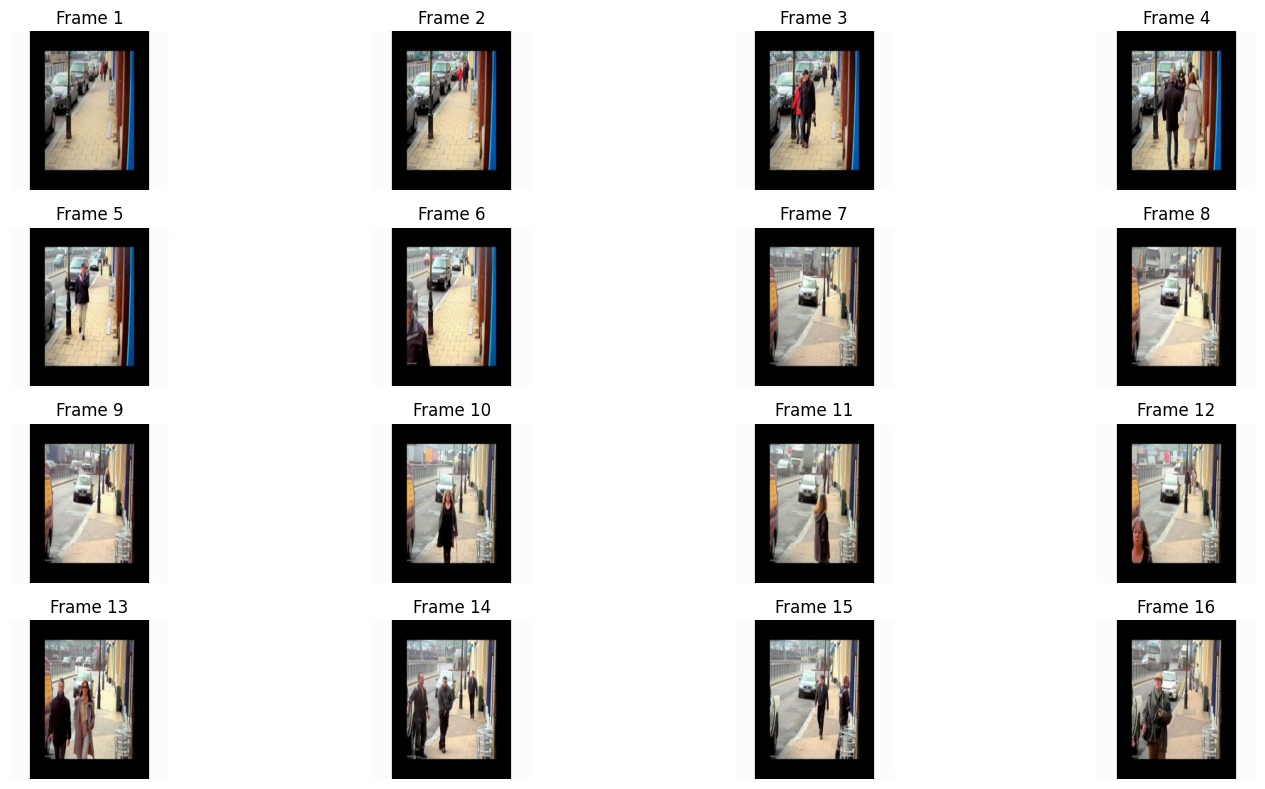

In [ ]:
import matplotlib.pyplot as plt

plt.figure(
    figsize=(16, 8)
)

for i in range(16):

    plt.subplot(
        4,
        4,
        i + 1
    )

    plt.imshow(frames[i])

    plt.title(
        f"Frame {i + 1}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import cv2
import numpy as np
import pandas as pd

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using Device:", device)

PyTorch Version: 2.11.0+cpu
CUDA Available: False
Using Device: cpu


In [ ]:
print("Train dataframe:", train_df.shape)
print("Validation dataframe:", val_df.shape)
print("Test dataframe:", test_df.shape)

print("\nTotal:",
      len(train_df) +
      len(val_df) +
      len(test_df))

Train dataframe: (598, 5)
Validation dataframe: (128, 5)
Test dataframe: (129, 5)

Total: 855


In [ ]:
from torchvision import transforms

frame_transform = transforms.Compose([

    transforms.ToPILImage(),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print(frame_transform)

Compose(
    ToPILImage()
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [ ]:
class ViolenceVideoDataset(Dataset):

    def __init__(
        self,
        dataframe,
        num_frames=16,
        image_size=224,
        transform=None
    ):

        self.dataframe = dataframe.reset_index(drop=True)
        self.num_frames = num_frames
        self.image_size = image_size
        self.transform = transform


    def __len__(self):

        return len(self.dataframe)


    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        video_path = row["path"]
        label = int(row["label"])

        # Sample frames from video
        frames = sample_video_frames(
            video_path,
            num_frames=self.num_frames,
            image_size=self.image_size
        )

        # Check correct number of frames
        if len(frames) != self.num_frames:
            raise ValueError(
                f"Expected {self.num_frames} frames, "
                f"but got {len(frames)} from:\n{video_path}"
            )

        processed_frames = []

        for frame in frames:

            if self.transform is not None:
                frame = self.transform(frame)

            processed_frames.append(frame)

        # [16, 3, 224, 224]
        frames_tensor = torch.stack(processed_frames)

        label_tensor = torch.tensor(
            label,
            dtype=torch.float32
        )

        return frames_tensor, label_tensor

In [ ]:
print("Train dataframe:", train_df.shape)
print("Validation dataframe:", val_df.shape)
print("Test dataframe:", test_df.shape)

print("\nTotal:",
      len(train_df) +
      len(val_df) +
      len(test_df))

Train dataframe: (598, 5)
Validation dataframe: (128, 5)
Test dataframe: (129, 5)

Total: 855


In [ ]:
train_dataset = ViolenceVideoDataset(
    dataframe=train_df,
    num_frames=NUM_FRAMES,
    image_size=IMAGE_SIZE,
    transform=frame_transform
)

val_dataset = ViolenceVideoDataset(
    dataframe=val_df,
    num_frames=NUM_FRAMES,
    image_size=IMAGE_SIZE,
    transform=frame_transform
)

test_dataset = ViolenceVideoDataset(
    dataframe=test_df,
    num_frames=NUM_FRAMES,
    image_size=IMAGE_SIZE,
    transform=frame_transform
)


print("Train videos      :", len(train_dataset))
print("Validation videos :", len(val_dataset))
print("Test videos       :", len(test_dataset))

print(
    "Total videos      :",
    len(train_dataset)
    + len(val_dataset)
    + len(test_dataset)
)

Train videos      : 598
Validation videos : 128
Test videos       : 129
Total videos      : 855


In [ ]:
frames_tensor, label = train_dataset[0]

print("Frame tensor shape :", frames_tensor.shape)
print("Label              :", label)
print("Tensor dtype       :", frames_tensor.dtype)

Frame tensor shape : torch.Size([16, 3, 224, 224])
Label              : tensor(0.)
Tensor dtype       : torch.float32


In [ ]:
# Training configuration

NUM_FRAMES = 16
IMAGE_SIZE = 224
BATCH_SIZE = 4

print("Frames per video :", NUM_FRAMES)
print("Image size       :", IMAGE_SIZE)
print("Batch size       :", BATCH_SIZE)

Frames per video : 16
Image size       : 224
Batch size       : 4


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Train batches      :", len(train_loader))
print("Validation batches :", len(val_loader))
print("Test batches       :", len(test_loader))

Train batches      : 150
Validation batches : 32
Test batches       : 33


In [ ]:
video_batch, label_batch = next(
    iter(train_loader)
)
print(
    "Video Batch Shape:",
    video_batch.shape
)
print(
    "Label Batch Shape:",
    label_batch.shape
)

Video Batch Shape: torch.Size([4, 16, 3, 224, 224])
Label Batch Shape: torch.Size([4])


In [ ]:
print(train_df["label"].value_counts().sort_index())

print("\n0 = Non-Violent")
print("1 = Violent")

label
0    260
1    338
Name: count, dtype: int64

0 = Non-Violent
1 = Violent


In [ ]:
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

class CNNBiLSTM(nn.Module):
    def __init__(
        self,
        hidden_size=256,
        num_layers=1,
        dropout=0.5
    ):

        super(CNNBiLSTM, self).__init__()

        # -----------------------------------------
        # PRETRAINED RESNET18
        # -----------------------------------------

        weights = ResNet18_Weights.DEFAULT

        self.cnn = resnet18(
            weights=weights
        )

        # ResNet18 produces 512 features before
        # the final classification layer
        self.cnn.fc = nn.Identity()

        self.feature_size = 512


        # -----------------------------------------
        # BIDIRECTIONAL LSTM
        # -----------------------------------------

        self.bilstm = nn.LSTM(
            input_size=self.feature_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True
        )
        # -----------------------------------------
        # DROPOUT
        # -----------------------------------------

        self.dropout = nn.Dropout(
            dropout
        )
        # -----------------------------------------
        # BINARY CLASSIFIER
        # -----------------------------------------

        # Bidirectional:
        # hidden_size * 2
        self.classifier = nn.Linear(
            hidden_size * 2,
            1
        )


    def forward(self, x):

        # Input:
        # [B, T, C, H, W]

        batch_size = x.size(0)
        sequence_length = x.size(1)

        # -----------------------------------------
        # COMBINE BATCH AND TIME
        # -----------------------------------------

        x = x.reshape(
            batch_size * sequence_length,
            x.size(2),
            x.size(3),
            x.size(4)
        )

        # Now:
        # [B*T, 3, 224, 224]


        # -----------------------------------------
        # CNN FEATURE EXTRACTION
        # -----------------------------------------

        features = self.cnn(x)

        # [B*T, 512]


        # -----------------------------------------
        # RESTORE VIDEO SEQUENCE
        # -----------------------------------------

        features = features.reshape(
            batch_size,
            sequence_length,
            self.feature_size
        )

        # [B, 16, 512]


        # -----------------------------------------
        # BiLSTM
        # -----------------------------------------

        lstm_output, _ = self.bilstm(
            features
        )

        # [B, 16, 512]
        # because 256 forward + 256 backward


        # -----------------------------------------
        # TEMPORAL POOLING
        # -----------------------------------------

        video_features = torch.mean(
            lstm_output,
            dim=1
        )

        # [B, 512]


        # -----------------------------------------
        # DROPOUT
        # -----------------------------------------

        video_features = self.dropout(
            video_features
        )


        # -----------------------------------------
        # CLASSIFICATION
        # -----------------------------------------

        logits = self.classifier(
            video_features
        )

        # [B, 1]

        return logits.squeeze(1)

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model = CNNBiLSTM(
    hidden_size=256,
    num_layers=1,
    dropout=0.5
)

model = model.to(device)

print(model.__class__.__name__)
print("Device:", device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 164MB/s]


CNNBiLSTM
Device: cpu


In [ ]:
video_batch, label_batch = next(
    iter(train_loader)
)

video_batch = video_batch.to(device)
label_batch = label_batch.to(device)

model.eval()

with torch.no_grad():

    logits = model(video_batch)

    probabilities = torch.sigmoid(logits)


print("Input Shape:")
print(video_batch.shape)

print("\nOutput Logits Shape:")
print(logits.shape)

print("\nLogits:")
print(logits)

print("\nViolence Probabilities:")
print(probabilities)

print("\nActual Labels:")
print(label_batch)

Input Shape:
torch.Size([4, 16, 3, 224, 224])

Output Logits Shape:
torch.Size([4])

Logits:
tensor([ 0.0692,  0.1993, -0.0080, -0.1354])

Violence Probabilities:
tensor([0.5173, 0.5497, 0.4980, 0.4662])

Actual Labels:
tensor([1., 0., 1., 1.])


In [ ]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")

Total Parameters     : 12,753,985
Trainable Parameters : 12,753,985


In [ ]:
# Freeze ResNet18
for param in model.cnn.parameters():
    param.requires_grad = False

# BiLSTM remains trainable
for param in model.bilstm.parameters():
    param.requires_grad = True

# Classifier remains trainable
for param in model.classifier.parameters():
    param.requires_grad = True


total_params = sum(
    p.numel() for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")

Total Parameters     : 12,753,985
Trainable Parameters : 1,577,473


In [ ]:
# Count classes in TRAINING DATA ONLY

class_counts = train_df["label"].value_counts()

num_negative = class_counts[0]   # Non-violent
num_positive = class_counts[1]   # Violent

print("Training Non-Violent :", num_negative)
print("Training Violent     :", num_positive)

# Positive-class weight
pos_weight_value = num_negative / num_positive

pos_weight = torch.tensor(
    [pos_weight_value],
    dtype=torch.float32,
    device=device
)

print("\nPositive Class Weight:", pos_weight_value)

Training Non-Violent : 260
Training Violent     : 338

Positive Class Weight: 0.7692307692307693


In [ ]:
criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

print(criterion)

BCEWithLogitsLoss()


In [ ]:
import torch.optim as optim

optimizer = optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=1e-4,
    weight_decay=1e-4
)

print(optimizer)

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)


In [ ]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print("Scheduler created.")

Scheduler created.


In [ ]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": [],
    "train_precision": [],
    "val_precision": [],
    "train_recall": [],
    "val_recall": [],
    "train_f1": [],
    "val_f1": []
}

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from tqdm.auto import tqdm


def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0

    all_labels = []
    all_predictions = []

    progress_bar = tqdm(
        loader,
        desc="Training",
        leave=False
    )

    for videos, labels in progress_bar:

        videos = videos.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        # Reset gradients
        optimizer.zero_grad()

        # Forward
        logits = model(videos)

        # Loss
        loss = criterion(
            logits,
            labels
        )

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += (
            loss.item() * videos.size(0)
        )

        # Probabilities
        probabilities = torch.sigmoid(
            logits
        )

        # Binary predictions
        predictions = (
            probabilities >= 0.5
        ).long()

        all_labels.extend(
            labels.detach().cpu().numpy()
        )

        all_predictions.extend(
            predictions.detach().cpu().numpy()
        )

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )


    epoch_loss = (
        running_loss / len(loader.dataset)
    )

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    precision = precision_score(
        all_labels,
        all_predictions,
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_predictions,
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_predictions,
        zero_division=0
    )


    return (
        epoch_loss,
        accuracy,
        precision,
        recall,
        f1
    )

In [ ]:
def validate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0

    all_labels = []
    all_predictions = []

    with torch.no_grad():

        progress_bar = tqdm(
            loader,
            desc="Validation",
            leave=False
        )

        for videos, labels in progress_bar:

            videos = videos.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            # Forward
            logits = model(videos)

            # Loss
            loss = criterion(
                logits,
                labels
            )

            running_loss += (
                loss.item() * videos.size(0)
            )

            probabilities = torch.sigmoid(
                logits
            )

            predictions = (
                probabilities >= 0.5
            ).long()

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )


    epoch_loss = (
        running_loss / len(loader.dataset)
    )

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    precision = precision_score(
        all_labels,
        all_predictions,
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_predictions,
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_predictions,
        zero_division=0
    )


    return (
        epoch_loss,
        accuracy,
        precision,
        recall,
        f1
    )

In [ ]:
CHECKPOINT_PATH = os.path.join(
    DATASET_PATH,
    "checkpoints"
)

os.makedirs(
    CHECKPOINT_PATH,
    exist_ok=True
)

BEST_MODEL_PATH = os.path.join(
    CHECKPOINT_PATH,
    "best_cnn_bilstm.pth"
)

print("Best model will be saved to:")
print(BEST_MODEL_PATH)

Best model will be saved to:
/content/drive/MyDrive/Violence_Detection_Dataset/checkpoints/best_cnn_bilstm.pth


In [ ]:
checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device
)

print("Saved epoch       :", checkpoint["epoch"])
print("Saved val loss    :", checkpoint["val_loss"])
print("Saved val accuracy:", checkpoint["val_accuracy"])
print("Saved val F1      :", checkpoint["val_f1"])

Saved epoch       : 2
Saved val loss    : 0.36803803965449333
Saved val accuracy: 0.8359375
Saved val F1      : 0.8627450980392157


In [ ]:
model.load_state_dict(
    checkpoint["model_state_dict"]
)

optimizer.load_state_dict(
    checkpoint["optimizer_state_dict"]
)

start_epoch = checkpoint["epoch"]

best_val_loss = checkpoint["val_loss"]

print("Checkpoint restored.")
print("Completed epochs :", start_epoch)
print("Resume from epoch:", start_epoch + 1)

Checkpoint restored.
Completed epochs : 2
Resume from epoch: 3


In [ ]:
NUM_EPOCHS = 10
EARLY_STOPPING_PATIENCE = 4

epochs_without_improvement = 0

for epoch in range(start_epoch, NUM_EPOCHS):

    print("\n" + "=" * 70)
    print(f"EPOCH {epoch + 1}/{NUM_EPOCHS}")
    print("=" * 70)

    (
        train_loss,
        train_acc,
        train_precision,
        train_recall,
        train_f1
    ) = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    (
        val_loss,
        val_acc,
        val_precision,
        val_recall,
        val_f1
    ) = validate(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_accuracy"].append(train_acc)
    history["val_accuracy"].append(val_acc)

    history["train_precision"].append(train_precision)
    history["val_precision"].append(val_precision)

    history["train_recall"].append(train_recall)
    history["val_recall"].append(val_recall)

    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)

    print("\nTRAIN")
    print(f"Loss      : {train_loss:.4f}")
    print(f"Accuracy  : {train_acc:.4f}")
    print(f"Precision : {train_precision:.4f}")
    print(f"Recall    : {train_recall:.4f}")
    print(f"F1 Score  : {train_f1:.4f}")

    print("\nVALIDATION")
    print(f"Loss      : {val_loss:.4f}")
    print(f"Accuracy  : {val_acc:.4f}")
    print(f"Precision : {val_precision:.4f}")
    print(f"Recall    : {val_recall:.4f}")
    print(f"F1 Score  : {val_f1:.4f}")

    scheduler.step(val_loss)

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        epochs_without_improvement = 0

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss": val_loss,
                "val_accuracy": val_acc,
                "val_f1": val_f1
            },
            BEST_MODEL_PATH
        )

        print("\n✓ Best model saved.")

    else:

        epochs_without_improvement += 1

        print(
            f"\nNo validation-loss improvement: "
            f"{epochs_without_improvement}/"
            f"{EARLY_STOPPING_PATIENCE}"
        )

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print("\nEarly stopping triggered.")
        break


EPOCH 3/10


Training:   0%|          | 0/150 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


TRAIN
Loss      : 0.4139
Accuracy  : 0.7742
Precision : 0.7959
Recall    : 0.8077
F1 Score  : 0.8018

VALIDATION
Loss      : 0.3647
Accuracy  : 0.8516
Precision : 0.9091
Recall    : 0.8219
F1 Score  : 0.8633

✓ Best model saved.

EPOCH 4/10


Training:   0%|          | 0/150 [00:00<?, ?it/s]

In [ ]:
print("Device:", device)
print("Train videos:", len(train_dataset))
print("Validation videos:", len(val_dataset))
print("Test videos:", len(test_dataset))
print("Batch size:", BATCH_SIZE)
print("Best model path:", BEST_MODEL_PATH)

Device: cuda
Train videos: 598
Validation videos: 128
Test videos: 129
Batch size: 4
Best model path: /content/drive/MyDrive/Violence_Detection_Dataset/checkpoints/best_cnn_bilstm.pth
